## $\text{Caso de Uso}$
## $\text{Predicción de Riesgo de Cancelación}$
## $\text{de planes pospago de telefonía móvil}$

MINE009



#PARA DOCUMENTAR EL README
**Interpretación de los Coeficientes del Modelo de Regresión Logística (en el contexto de las variables escaladas/codificadas):**

Los coeficientes de la regresión logística representan el cambio en el logaritmo de las probabilidades (log-odds) de que la variable objetivo (`RIESGO_CANCELACION_si` sea 1) por cada incremento de una unidad en la variable predictora correspondiente, manteniendo todas las demás variables constantes.

Dado que las variables numéricas fueron escaladas con `StandardScaler`, un incremento de una unidad en una variable numérica escalada corresponde a un incremento de una desviación estándar en la unidad original de esa variable. Para las variables categóricas codificadas con One-Hot Encoding, el coeficiente representa el cambio en el log-odds cuando esa categoría específica está presente en comparación con la categoría de referencia (la que se eliminó).

*   **Coeficientes Positivos**: Un coeficiente positivo indica que a medida que aumenta el valor de la variable (o la categoría está presente), el log-odds de tener `RIESGO_CANCELACION_si` = 1 (riesgo de cancelación) aumenta, haciendo que la cancelación sea **más probable**.
*   **Coeficientes Negativos**: Un coeficiente negativo indica que a medida que aumenta el valor de la variable (o la categoría está presente), el log-odds de tener `RIESGO_CANCELACION_si` = 1 disminuye, haciendo que la cancelación sea **menos probable**.
*   **Magnitud del Coeficiente**: La magnitud absoluta del coeficiente indica la fuerza de la relación. Un valor absoluto mayor sugiere un impacto más fuerte en el log-odds de cancelación.

Observando los coeficientes calculados:

*   Las variables con los mayores coeficientes positivos (y por lo tanto, que más aumentan el riesgo de cancelación) parecen ser `NUM_INTERRUPCIONES` y `DIAS_PAGO_FACT`. Esto sugiere que un mayor número de interrupciones en el servicio y un mayor retraso en los días de pago de la factura están fuertemente asociados con un mayor riesgo de cancelación.
*   La variable `SUSCRIP_STREAMING_si` tiene un coeficiente negativo grande. Esto indica que tener suscripción de streaming está fuertemente asociado con una **menor** probabilidad de cancelación en comparación con no tener suscripción de streaming (la categoría de referencia).
*   Otras variables como `VECES_LLAM_COMPETENCIA` y `DUR_INTERRUPCIONES` también tienen coeficientes positivos notables, aunque de menor magnitud, lo que sugiere que un mayor número de llamadas a la competencia y una mayor duración de las interrupciones también aumentan el riesgo de cancelación.
*   Las variables `EDAD`, `ESTRATO_VIVIENDA`, `MIN_LLAMADAS_SEM`, `MIN_REDES_SOC_SEM`, `MIN_WEB_SEM`, `MESES_SUSCRITO`, y las variables recodificadas de `GENERO`, `NIVEL_EDUCATIVO`, y `TIPO_AREA_VIVIENDA` tienen coeficientes más cercanos a cero, lo que sugiere una menor influencia (en este modelo) en el riesgo de cancelación en comparación con las variables mencionadas anteriormente.
*   Dentro de las variables categóricas, `SEGMENTO_PLAN_medio` tiene un coeficiente positivo, lo que implica que tener un plan 'medio' se asocia con un mayor riesgo de cancelación en comparación con el plan base (la categoría de referencia). `SEGMENTO_PLAN_premium` tiene un coeficiente negativo, sugiriendo un menor riesgo en comparación con el plan base.

Es importante recordar que esta interpretación se basa en el modelo entrenado y las relaciones encontradas en los datos. No implica causalidad directa.

# *1. Carga de Librerías y Datos*

In [3]:
# Cargue librerías para procesamiento de datos y la regresión logística

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv('../data/RAW/dataset_pospago.csv', sep=";")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   EDAD                    10000 non-null  int64 
 1   GENERO                  10000 non-null  object
 2   ESTRATO_VIVIENDA        10000 non-null  int64 
 3   NIVEL_EDUCATIVO         10000 non-null  object
 4   TIPO_AREA_VIVIENDA      10000 non-null  object
 5   SEGMENTO_PLAN           10000 non-null  object
 6   MIN_LLAMADAS_SEM        10000 non-null  int64 
 7   MIN_REDES_SOC_SEM       10000 non-null  int64 
 8   MIN_WEB_SEM             10000 non-null  int64 
 9   DIAS_PAGO_FACT          10000 non-null  int64 
 10  VECES_LLAM_COMPETENCIA  10000 non-null  int64 
 11  MESES_SUSCRITO          10000 non-null  int64 
 12  NUM_INTERRUPCIONES      10000 non-null  int64 
 13  DUR_INTERRUPCIONES      10000 non-null  int64 
 14  SUSCRIP_STREAMING       10000 non-null  object
 15  RIE

In [17]:
#convertir la variable estrato en variable tipo categórica
df['ESTRATO_VIVIENDA'] = df['ESTRATO_VIVIENDA'].astype('object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   EDAD                    10000 non-null  int64 
 1   GENERO                  10000 non-null  object
 2   ESTRATO_VIVIENDA        10000 non-null  object
 3   NIVEL_EDUCATIVO         10000 non-null  object
 4   TIPO_AREA_VIVIENDA      10000 non-null  object
 5   SEGMENTO_PLAN           10000 non-null  object
 6   MIN_LLAMADAS_SEM        10000 non-null  int64 
 7   MIN_REDES_SOC_SEM       10000 non-null  int64 
 8   MIN_WEB_SEM             10000 non-null  int64 
 9   DIAS_PAGO_FACT          10000 non-null  int64 
 10  VECES_LLAM_COMPETENCIA  10000 non-null  int64 
 11  MESES_SUSCRITO          10000 non-null  int64 
 12  NUM_INTERRUPCIONES      10000 non-null  int64 
 13  DUR_INTERRUPCIONES      10000 non-null  int64 
 14  SUSCRIP_STREAMING       10000 non-null  object
 15  RIE

In [19]:
df.head()

,EDAD,GENERO,ESTRATO_VIVIENDA,NIVEL_EDUCATIVO,TIPO_AREA_VIVIENDA,SEGMENTO_PLAN,MIN_LLAMADAS_SEM,MIN_REDES_SOC_SEM,MIN_WEB_SEM,DIAS_PAGO_FACT,VECES_LLAM_COMPETENCIA,MESES_SUSCRITO,NUM_INTERRUPCIONES,DUR_INTERRUPCIONES,SUSCRIP_STREAMING,RIESGO_CANCELACION
0,57,mujer,2,primaria,urbana,basico,414,1599,61,38,285,84,4,34,no,no
1,53,hombre,4,primaria,urbana,medio,634,697,1258,37,140,118,4,416,no,si
2,43,mujer,4,educacion superior,urbana,premium,596,1801,305,4,54,6,6,76,si,no
3,39,hombre,3,educacion superior,rural,premium,473,727,1205,15,281,113,8,302,no,si
4,63,hombre,1,educacion superior,rural,premium,694,993,1366,25,254,40,4,428,no,si


# *2. Análisis Exploratorio de Datos (EDA)*

In [20]:
# Estadística Descriptiva de variables numéricas:
print("\nEstadística Descriptiva de variables numéricas:")
display(df.describe())


Estadística Descriptiva de variables numéricas:


,EDAD,MIN_LLAMADAS_SEM,MIN_REDES_SOC_SEM,MIN_WEB_SEM,DIAS_PAGO_FACT,VECES_LLAM_COMPETENCIA,MESES_SUSCRITO,NUM_INTERRUPCIONES,DUR_INTERRUPCIONES
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,48.144900,503.481700,1008.046100,749.755300,33.474500,162.956900,60.046600,5.747000,262.165400
std,18.740006,289.596043,577.348823,432.721325,16.097747,80.927129,34.607554,2.859512,139.301909
min,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,32.000000,253.000000,512.000000,374.000000,21.000000,97.000000,30.000000,4.000000,144.000000
50%,48.000000,502.000000,1012.000000,748.500000,34.000000,163.000000,60.000000,6.000000,261.000000
75%,64.000000,756.250000,1507.250000,1123.000000,47.000000,232.000000,90.000000,8.000000,385.000000
max,80.000000,1000.000000,2000.000000,1500.000000,60.000000,300.000000,120.000000,10.000000,500.000000


In [21]:
# Conteos para las variables categóricas
print("\nConteos para las variables categóricas")
for col in df.select_dtypes(include='object'):
    print(f"\nValue counts for column '{col}':")
    print(df[col].value_counts())


Conteos para las variables categóricas

Value counts for column 'GENERO':
GENERO
mujer     4597
hombre    4524
otro       879
Name: count, dtype: int64

Value counts for column 'ESTRATO_VIVIENDA':
ESTRATO_VIVIENDA
5    1692
2    1678
6    1661
4    1657
1    1656
3    1656
Name: count, dtype: int64

Value counts for column 'NIVEL_EDUCATIVO':
NIVEL_EDUCATIVO
primaria              3364
secundaria            3350
educacion superior    3286
Name: count, dtype: int64

Value counts for column 'TIPO_AREA_VIVIENDA':
TIPO_AREA_VIVIENDA
urbana    5087
rural     4913
Name: count, dtype: int64

Value counts for column 'SEGMENTO_PLAN':
SEGMENTO_PLAN
medio      3360
basico     3335
premium    3305
Name: count, dtype: int64

Value counts for column 'SUSCRIP_STREAMING':
SUSCRIP_STREAMING
no    7463
si    2537
Name: count, dtype: int64

Value counts for column 'RIESGO_CANCELACION':
RIESGO_CANCELACION
no    5044
si    4956
Name: count, dtype: int64


## Histogramas

* Variable objetivo: RIESGO_CANCELACION

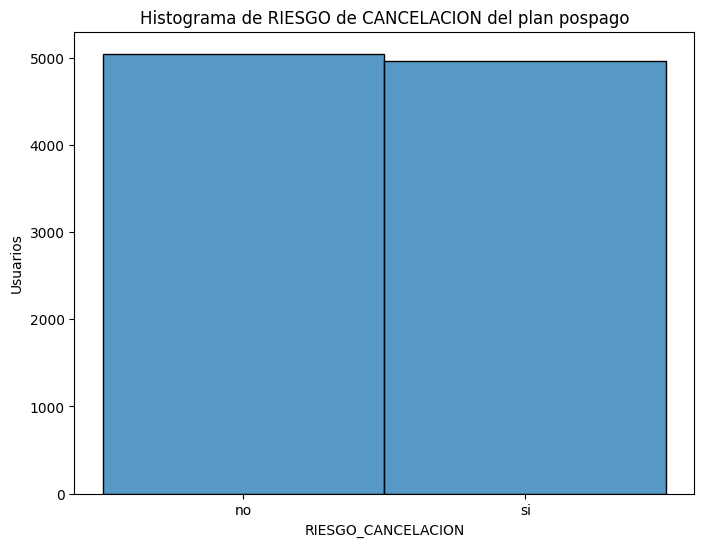

In [22]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='RIESGO_CANCELACION', bins=20, kde=False)
plt.title('Histograma de RIESGO de CANCELACION del plan pospago')
plt.xlabel('RIESGO_CANCELACION')
plt.ylabel('Usuarios')
plt.show()

* Variable: MESES_SUSCRITO

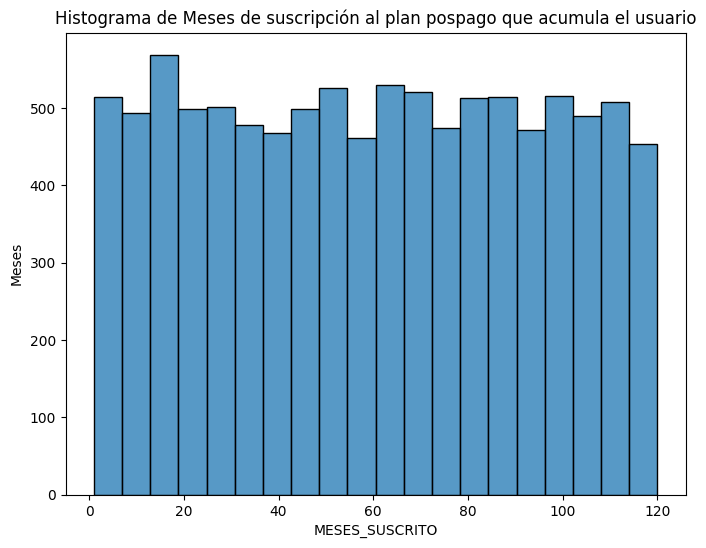

In [23]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='MESES_SUSCRITO', bins=20, kde=False)
plt.title('Histograma de Meses de suscripción al plan pospago que acumula el usuario')
plt.xlabel('MESES_SUSCRITO')
plt.ylabel('Meses')
plt.show()

* Variable: SEGMENTO_PLAN

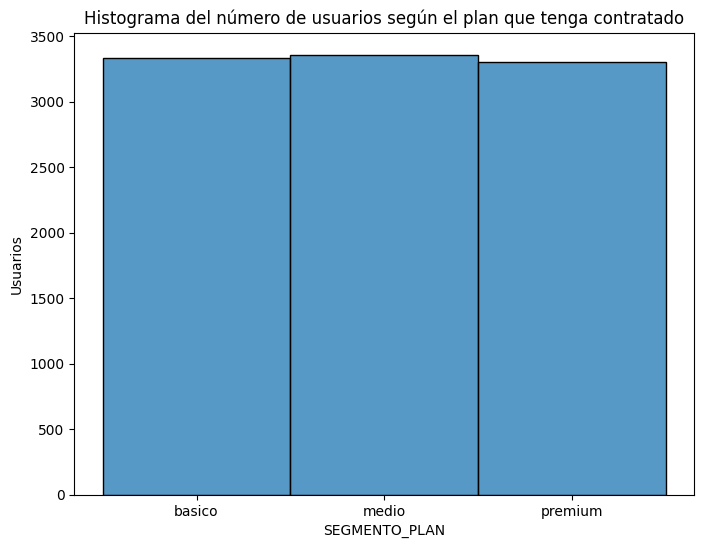

In [24]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='SEGMENTO_PLAN', bins=20, kde=False)
plt.title('Histograma del número de usuarios según el plan que tenga contratado')
plt.xlabel('SEGMENTO_PLAN')
plt.ylabel('Usuarios')
plt.show()

## Boxplot

* Boxplot cruzado entre las variables `NUM_INTERRUPCIONES` y `RIESGO_CANCELACION`

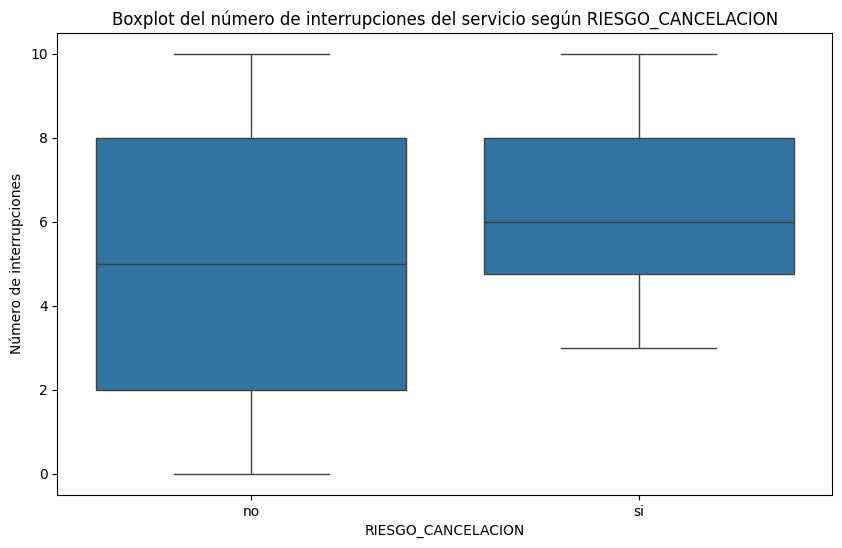

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='RIESGO_CANCELACION', y='NUM_INTERRUPCIONES')
plt.title('Boxplot del número de interrupciones del servicio según RIESGO_CANCELACION')
plt.xlabel('RIESGO_CANCELACION')
plt.ylabel('Número de interrupciones')
plt.show()

## Matriz de correlación

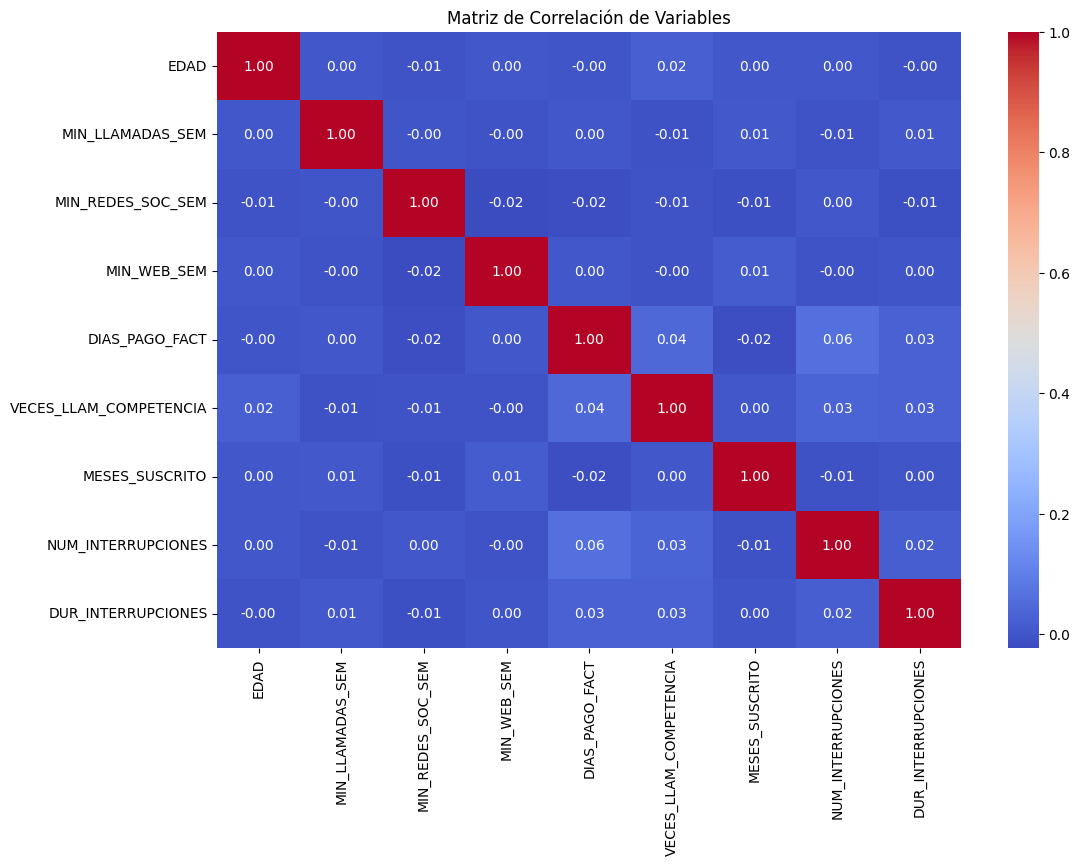

In [26]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables')
plt.show()

# *3. Preprocesamiento de Datos*

Se separa el conjunto de datos entre entrenamiento `train` (70%) y prueba `test` (30%)

In [ ]:
# Definir las características (X) y la variable objetivo (y)
X = df.drop('RIESGO_CANCELACION', axis=1)
y = df['RIESGO_CANCELACION']
y = y.map({'si': 1, 'no': 0})

# Dividir el conjunto de datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

9069    1
2603    0
7738    0
1579    0
5058    1
       ..
5734    1
5191    1
5390    1
860     1
7270    0
Name: RIESGO_CANCELACION, Length: 7000, dtype: int64
Dimensiones de X_train: (7000, 15)
Dimensiones de X_test: (3000, 15)
Dimensiones de y_train: (7000,)
Dimensiones de y_test: (3000,)


In [67]:
# Identificar columnas categóricas incluyendo la variable de respuesta
columnas_categoricas = X_train.select_dtypes(include='object').columns
columnas_categoricas

Index(['GENERO', 'ESTRATO_VIVIENDA', 'NIVEL_EDUCATIVO', 'TIPO_AREA_VIVIENDA',
       'SEGMENTO_PLAN', 'SUSCRIP_STREAMING'],
      dtype='object')

In [ ]:
# Identificar columnas numéricas
columnas_numericas = X_train.select_dtypes(exclude='object').columns
columnas_numericas

Index(['EDAD', 'MIN_LLAMADAS_SEM', 'MIN_REDES_SOC_SEM', 'MIN_WEB_SEM',
       'DIAS_PAGO_FACT', 'VECES_LLAM_COMPETENCIA', 'MESES_SUSCRITO',
       'NUM_INTERRUPCIONES', 'DUR_INTERRUPCIONES'],
      dtype='object')

### Exploración transformaciones de columnas

In [41]:
# Aplicar one-hot encoding con valores 1 y 0
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# Mostrar las primeras filas del DataFrame codificado
print("DataFrame después de One-Hot Encoding:")
display(df_encoded.head())

# Mostrar las columnas del DataFrame codificado
print("\nColumnas del DataFrame codificado:")
print(df_encoded.columns)

DataFrame después de One-Hot Encoding:


,EDAD,MIN_LLAMADAS_SEM,MIN_REDES_SOC_SEM,MIN_WEB_SEM,DIAS_PAGO_FACT,VECES_LLAM_COMPETENCIA,MESES_SUSCRITO,NUM_INTERRUPCIONES,DUR_INTERRUPCIONES,GENERO_mujer,...,ESTRATO_VIVIENDA_4,ESTRATO_VIVIENDA_5,ESTRATO_VIVIENDA_6,NIVEL_EDUCATIVO_primaria,NIVEL_EDUCATIVO_secundaria,TIPO_AREA_VIVIENDA_urbana,SEGMENTO_PLAN_medio,SEGMENTO_PLAN_premium,SUSCRIP_STREAMING_si,RIESGO_CANCELACION_si
0,57,414,1599,61,38,285,84,4,34,1,...,0,0,0,1,0,1,0,0,0,0
1,53,634,697,1258,37,140,118,4,416,0,...,1,0,0,1,0,1,1,0,0,1
2,43,596,1801,305,4,54,6,6,76,1,...,1,0,0,0,0,1,0,1,1,0
3,39,473,727,1205,15,281,113,8,302,0,...,0,0,0,0,0,0,0,1,0,1
4,63,694,993,1366,25,254,40,4,428,0,...,0,0,0,0,0,0,0,1,0,1



Columnas del DataFrame codificado:
Index(['EDAD', 'MIN_LLAMADAS_SEM', 'MIN_REDES_SOC_SEM', 'MIN_WEB_SEM',
       'DIAS_PAGO_FACT', 'VECES_LLAM_COMPETENCIA', 'MESES_SUSCRITO',
       'NUM_INTERRUPCIONES', 'DUR_INTERRUPCIONES', 'GENERO_mujer',
       'GENERO_otro', 'ESTRATO_VIVIENDA_2', 'ESTRATO_VIVIENDA_3',
       'ESTRATO_VIVIENDA_4', 'ESTRATO_VIVIENDA_5', 'ESTRATO_VIVIENDA_6',
       'NIVEL_EDUCATIVO_primaria', 'NIVEL_EDUCATIVO_secundaria',
       'TIPO_AREA_VIVIENDA_urbana', 'SEGMENTO_PLAN_medio',
       'SEGMENTO_PLAN_premium', 'SUSCRIP_STREAMING_si',
       'RIESGO_CANCELACION_si'],
      dtype='object')


In [54]:
from sklearn.preprocessing import StandardScaler

# Seleccionar columnas numéricas (excluyendo la variable objetivo si es numérica)
# Asumimos que 'RIESGO_CANCELACION' es la variable objetivo y puede ser numérica o ya codificada.
# Si 'RIESGO_CANCELACION' es numérica y no quieres escalarla, exclúyela.
# Por ahora, escalaremos todas las columnas numéricas restantes.
numerical_cols = ['EDAD', 'MIN_LLAMADAS_SEM', 'MIN_REDES_SOC_SEM', 'MIN_WEB_SEM', 'DIAS_PAGO_FACT', 'VECES_LLAM_COMPETENCIA', 'MESES_SUSCRITO', 'NUM_INTERRUPCIONES', 'DUR_INTERRUPCIONES']

# Si 'RIESGO_CANCELACION_si' está en las columnas numéricas y no debe ser escalada, elimínala de la lista
if 'RIESGO_CANCELACION' in numerical_cols:
    numerical_cols.remove('RIESGO_CANCELACION')

# Mostrar las columnas que se van a escalar
print("Columnas que se van a escalar:")
print(numerical_cols)

Columnas que se van a escalar:
['EDAD', 'MIN_LLAMADAS_SEM', 'MIN_REDES_SOC_SEM', 'MIN_WEB_SEM', 'DIAS_PAGO_FACT', 'VECES_LLAM_COMPETENCIA', 'MESES_SUSCRITO', 'NUM_INTERRUPCIONES', 'DUR_INTERRUPCIONES']


In [55]:
# Inicializar el StandardScaler
scaler = StandardScaler()

# Aplicar StandardScaler a las columnas numéricas
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# Mostrar las primeras filas del DataFrame normalizado
print("\nDataFrame después de la normalización con StandardScaler:")
display(df_encoded.head())


DataFrame después de la normalización con StandardScaler:


,EDAD,MIN_LLAMADAS_SEM,MIN_REDES_SOC_SEM,MIN_WEB_SEM,DIAS_PAGO_FACT,VECES_LLAM_COMPETENCIA,MESES_SUSCRITO,NUM_INTERRUPCIONES,DUR_INTERRUPCIONES,GENERO_mujer,...,ESTRATO_VIVIENDA_4,ESTRATO_VIVIENDA_5,ESTRATO_VIVIENDA_6,NIVEL_EDUCATIVO_primaria,NIVEL_EDUCATIVO_secundaria,TIPO_AREA_VIVIENDA_urbana,SEGMENTO_PLAN_medio,SEGMENTO_PLAN_premium,SUSCRIP_STREAMING_si,RIESGO_CANCELACION_si
0,0.472547,-0.309003,1.023616,-1.591763,0.281140,1.508137,0.692178,-0.610974,-1.638002,1,...,0,0,0,1,0,1,0,0,0,0
1,0.259090,0.450713,-0.538776,1.174590,0.219017,-0.283688,1.674672,-0.610974,1.104380,0,...,1,0,0,1,0,1,1,0,0,1
2,-0.274555,0.319490,1.373509,-1.027861,-1.831062,-1.346425,-1.561778,0.088481,-1.336484,1,...,1,0,0,0,0,1,0,1,1,0
3,-0.488013,-0.105261,-0.486812,1.052103,-1.147702,1.458707,1.530188,0.787936,0.285973,0,...,0,0,0,0,0,0,0,1,0,1
4,0.792734,0.657909,-0.026062,1.424186,-0.526466,1.125057,-0.579284,-0.610974,1.190528,0,...,0,0,0,0,0,0,0,1,0,1


Se normalizan la escala de las variables numéricas, este aspecto puede alterar el algoritmo de regresión.

Se propone aplicar el onehot encoder para generar variables dummy a partir de las variables originales categóricas, así como imputar los valores nulos, en caso de que se presenten en los datos de prueba o en los proporcionados por el usuario de la API.
 
Finalmente, se explora una estandarización de los valores de las variables numéricas, para que las escalas de las mismas no afecten la magnitud de los coeficientes calculados en el entrenamiento del modelo.

Habiendo realizado estas pruebas, se procede a armar el artefacto de preprocesamiento con los pases antes descritos.

### Artefacto de preprocesamiento de los datos

In [47]:
### Transformación de las variables
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
 
# Creación de los pasos para el preprocesamiento
 
## El tratamiento en variables categoricas
# Si bien el conjunto de datos no tiene nan, se programa la imputación en caso de que
# aparezcan en los datos de testeo o en los ingresados por el usuario
transformacion_nan=SimpleImputer(strategy='constant', fill_value='-')
transfomacion_OHE=OneHotEncoder(sparse_output=False, handle_unknown='ignore')
 
pasos_categoricas = [
    ('imputacion', transformacion_nan),
    ('codificacion', transfomacion_OHE),]
 
### El tratamiento en variables numericas
 
transformacion_escalar=StandardScaler()
pasos_numericas=[('normalizacion_escalar',transformacion_escalar)]
 
 
pipeline_categorico=Pipeline(pasos_categoricas)
pipeline_numerico=Pipeline(pasos_numericas)
 
# Creación del preprocesador
Transformacion_Columnas = ColumnTransformer(
    transformers=[('Tratamiento_categorico',pipeline_categorico, columnas_categoricas),    
                  ('Tratamiento_numerico',pipeline_numerico, columnas_numericas),                
                  ])
 
Transformacion_Columnas

,transformers,"[('Tratamiento_categorico', ...), ('Tratamiento_numerico', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,'-'


In [ ]:
# Entrenamiento del transformador
Transformacion_Columnas.fit(X_train) # Ajusta los pasos definidos en el pipeline

,transformers,"[('Tratamiento_categorico', ...), ('Tratamiento_numerico', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,'-'


In [ ]:
# Transformacion de las columnas con el artefacto
Transformacion_Columnas.transform(X_train) #Aplica los pasos definidos en el pipeline

array([[ 0.        ,  0.        ,  1.        , ...,  0.78214264,
        -0.9565296 ,  1.6417186 ],
       [ 1.        ,  0.        ,  0.        , ..., -1.30241297,
         0.79370754, -0.00164234],
       [ 0.        ,  1.        ,  0.        , ...,  0.34786022,
        -1.30657703,  0.12035389],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.02851788,
        -0.60648217,  0.97432748],
       [ 1.        ,  0.        ,  0.        , ...,  1.04271209,
         0.79370754,  1.1393812 ],
       [ 0.        ,  1.        ,  0.        , ...,  0.89795128,
         0.79370754, -1.03502214]], shape=(7000, 28))

# *4. Modelado y Entrenamiento*

In [68]:
# Creación del modelo de Regresión Logística
model = LogisticRegression()

print("Modelo de Regresión Logística instanciado:")
print(model)

Modelo de Regresión Logística instanciado:
LogisticRegression()


In [75]:
# Entrenar el modelo con los datos de entrenamiento
model.fit(Transformacion_Columnas.transform(X_train), y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# *5. Evaluación del Modelo*

* Se realizan predicciones ahora con los datos de prueba (`X_test`)

In [77]:
# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(Transformacion_Columnas.transform(X_test))

In [78]:
# Mostrar las predicciones
print("Predicciones del modelo en el conjunto de prueba:")
display(y_pred)

Predicciones del modelo en el conjunto de prueba:


array([1, 0, 1, ..., 1, 0, 1], shape=(3000,))

* Se calculan las métricas de la evaluación del modelo:
    * Matriz de confusión
    * Métricas de Precisión (Precision), Sensibilidad (Recall) y Puntuación F1 (F1-Score)
    * Curvas ROC y AUC

In [79]:
confusion_matrix(y_test,y_pred) #Importante que en esta función, escribamos primero y_test y luego y_pred

array([[1090,  465],
       [ 128, 1317]])

In [80]:
# Calcular e imprimir el reporte de clasificación del modelo de regresión logística
print("\nReporte de Clasificación del modelo de regresión logística:")
print(classification_report(y_test, y_pred))


Reporte de Clasificación del modelo de regresión logística:
              precision    recall  f1-score   support

           0       0.89      0.70      0.79      1555
           1       0.74      0.91      0.82      1445

    accuracy                           0.80      3000
   macro avg       0.82      0.81      0.80      3000
weighted avg       0.82      0.80      0.80      3000



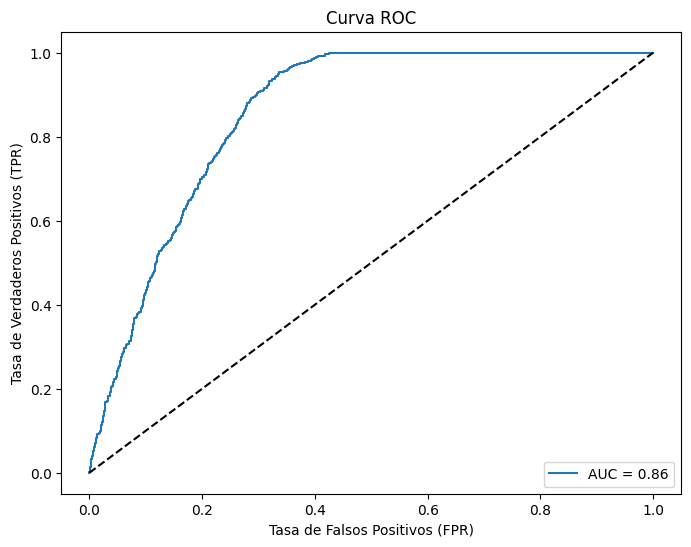


Área bajo la Curva ROC (AUC): 0.86


In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

# Obtener las probabilidades de predicción para la clase positiva (RIESGO_CANCELACION_si = 1)
y_prob = model.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcular el Área bajo la Curva ROC (AUC)
auc = roc_auc_score(y_test, y_prob)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--') # Línea de referencia aleatoria
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

print(f"\nÁrea bajo la Curva ROC (AUC): {auc:.2f}")

**Interpretación:**

* Curva ROC (Receiver Operating Characteristic Curve): Es una gráfica que muestra el rendimiento de un modelo de clasificación en todos los umbrales de clasificación posibles. Compara la Tasa de Verdaderos Positivos (TPR) o Sensibilidad, que es la proporción de positivos reales que se identifican correctamente, frente a la Tasa de Falsos Positivos (FPR), que es la proporción de negativos reales que se identifican incorrectamente como positivos. Una curva ROC que se acerca a la esquina superior izquierda del gráfico indica un mejor rendimiento del modelo. La línea diagonal punteada representa un clasificador aleatorio.

* Área bajo la Curva ROC (AUC - Area Under the Curve): Es una métrica escalar que cuantifica el rendimiento general de un modelo de clasificación. Representa la probabilidad de que el modelo clasifique correctamente un par elegido al azar de una instancia positiva y una instancia negativa. El valor del AUC varía entre 0 y 1. Un AUC de 0.5 sugiere que el modelo no es mejor que un clasificador aleatorio, mientras que un AUC de 1.0 representa un clasificador perfecto.

* En este caso, el **AUC obtenido es 0.86**. Esto indica que **el modelo tiene una buena capacidad para distinguir entre las clases positiva (riesgo de cancelación) y negativa (sin riesgo de cancelación)**. Un valor de 0.86 sugiere un rendimiento _considerablemente mejor que el de un clasificador aleatorio (AUC = 0.5)_. En general, un AUC entre 0.80 y 0.90 se considera un buen rendimiento predictivo.

* Precisión (Precision): La capacidad del clasificador para no etiquetar como positivo una muestra que es negativa. Para la clase '0' (sin riesgo de cancelación), la precisión es 0.89, lo que significa que cuando el modelo predice 'sin riesgo', acierta el 89% de las veces. Para la clase '1' (riesgo de cancelación), la precisión es 0.73, lo que indica que cuando el modelo predice 'riesgo', acierta el 73% de las veces.

* Sensibilidad (Recall): La capacidad del clasificador para encontrar todas las muestras positivas. Para la clase '0', la sensibilidad es 0.69, lo que significa que el modelo identifica correctamente el 69% de los casos reales 'sin riesgo'. Para la clase '1', la sensibilidad es 0.91, lo que indica que el modelo identifica correctamente el 91% de los casos reales con 'riesgo'. Esto sugiere que el modelo es bastante bueno detectando usuarios con riesgo de cancelación.

* Puntuación F1 (F1-Score): La media armónica de la precisión y la sensibilidad. Es una buena medida de la exactitud de un modelo en un conjunto de datos. Para la clase '0', la puntuación F1 es 0.78, y para la clase '1', es 0.81.
Soporte (Support): El número de ocurrencias reales de la clase en el conjunto de datos especificado. Hay 1555 instancias de 'sin riesgo' (0) y 1445 instancias de 'riesgo' (1) en el conjunto de prueba.

* Exactitud (Accuracy): La proporción de instancias correctamente predichas con respecto al número total de instancias. La exactitud general del modelo es 0.80, lo que significa que predice correctamente el riesgo de cancelación para el 80% de los usuarios en el conjunto de prueba.

* Macro Avg: El promedio de la precisión, sensibilidad y puntuación F1 para cada clase, sin considerar el desbalance de clases.

* Weighted Avg: El promedio de la precisión, sensibilidad y puntuación F1 para cada clase, ponderado por el número de instancias en cada clase. Esta es una métrica más apropiada cuando se trabaja con conjuntos de datos desbalanceados.


En resumen, el modelo tiene una exactitud general del 80%. Es particularmente bueno identificando a los usuarios que están en riesgo de cancelación (alta sensibilidad para la clase 1), lo cual suele ser una prioridad en escenarios de predicción de abandono (churn prediction). Sin embargo, tiene una precisión ligeramente menor para la clase 1, lo que significa que a veces predice incorrectamente que un usuario está en riesgo cuando no lo está.

In [86]:
### Revisamos varios modelos a la vez con GridSearchCV
 
from sklearn.model_selection import GridSearchCV
 
model = LogisticRegression()
 
# Definición de los hiperparámetros a optimizar
parametros = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['saga'],
    'l1_ratio': [0.1, 0.5, 0.9]
}
 
# Inicializa GridSearchCV
grid_search = GridSearchCV(estimator=model,
                           param_grid=parametros,
                           cv=5, # Número de validaciones cruzadas
                           scoring='accuracy', # Métrica de evaluación
                           n_jobs=-1,
	         verbose=2) # Usa todos los núcleos disponibles
 
# Agregamos el entrenamiento del modelo con las combinaciones que calcula GridSearchCV al pipeline
 
from sklearn.pipeline import Pipeline
 
# Creación del pipeline
 
pipeline = Pipeline(steps=[('preprocesamiento', Transformacion_Columnas),
                           ('modelo', grid_search)])
 
pipeline

,steps,"[('preprocesamiento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Tratamiento_categorico', ...), ('Tratamiento_numerico', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [87]:
#automatización del modelo junto al preprocesamiento de los datos
pipeline.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,steps,"[('preprocesamiento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Tratamiento_categorico', ...), ('Tratamiento_numerico', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# *6. Interpretación de Resultados*

Se validan los mejores parámetros encontrados por grid search

In [88]:
pipeline.named_steps['modelo'].best_params_

{'C': 0.01, 'l1_ratio': 0.9, 'penalty': 'elasticnet', 'solver': 'saga'}



---



In [89]:
### Evaluación del mejor modelo
 
y_pred = pipeline.predict(X_test)
 
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1046  509]
 [  86 1359]]
              precision    recall  f1-score   support

           0       0.92      0.67      0.78      1555
           1       0.73      0.94      0.82      1445

    accuracy                           0.80      3000
   macro avg       0.83      0.81      0.80      3000
weighted avg       0.83      0.80      0.80      3000



# *7. Almacenamiento del modelo*

In [92]:
### Guardamos el pipeline
 
import joblib
 
# Guardar el entrenamiento del modelo
joblib.dump(pipeline, '../data/Processed/pipeline.pkl')

['../data/Processed/pipeline.pkl']

In [93]:
### Probar el modelo desde el archivo .pkl
modelo_cargado= joblib.load('../data/Processed/pipeline.pkl')
modelo_cargado.predict(X_test.iloc[:5])

array([1, 0, 1, 1, 1])